In [1]:
from matplotlib import rcParams
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from mplsoccer import Pitch, FontManager, Sbopen

rcParams['text.color'] = '#c7d5cc'  # set the default text color

# get event dataframe for game 7478
parser = Sbopen()
df, related, freeze, tactics = parser.event(3857283)

In [2]:
morocco, belguim = df.team_name.unique()
mask_morocco = (df.type_name == 'Pass') & (df.team_name == morocco)

In [3]:
df_pass = df.loc[mask_morocco, ['x', 'y', 'end_x', 'end_y', 'outcome_name']]
mask_complete = df_pass.outcome_name.isnull()

In [5]:
pitch = Pitch(pitch_type='statsbomb',  line_zorder=2, line_color='#c7d5cc', pitch_color='#22312b')
bins = (6, 4)

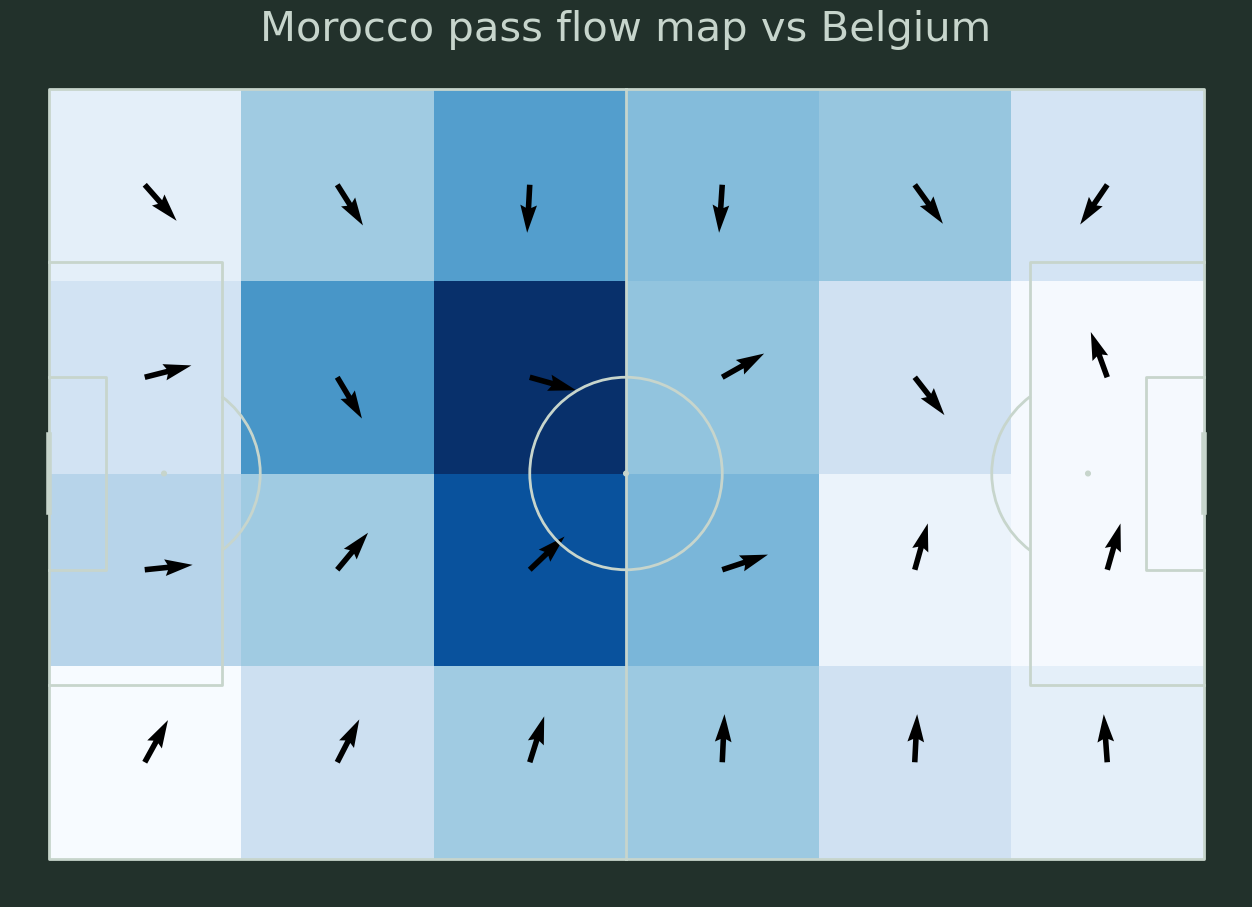

In [10]:
fig, ax = pitch.draw(figsize=(16, 11), constrained_layout=True, tight_layout=False)
fig.set_facecolor('#22312b')
# plot the heatmap - darker colors = more passes originating from that square
bs_heatmap = pitch.bin_statistic(df_pass.x, df_pass.y, statistic='count', bins=bins)
hm = pitch.heatmap(bs_heatmap, ax=ax, cmap='Blues')
# plot the pass flow map with a single color ('black') and length of the arrow (5)
fm = pitch.flow(df_pass.x, df_pass.y, df_pass.end_x, df_pass.end_y,
                color='black', arrow_type='same',
                arrow_length=5, bins=bins, ax=ax)
ax_title = ax.set_title(f'{belguim} pass flow map vs {morocco}', fontsize=30, pad=-20)
